# Import Library (Menyiapkan Library)
## Mengimport library python yang akan di pakai seperti:
### - Pandas : untuk membaca data menjadi data tabular, memanipulasi data, pembersihan data dll
### - Numpy : untuk memperoses data numeric dan manipulasi array dengan efisien
### - Matplotlib & Seaborn : untuk memvisualisasikan data

In [333]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import scipy.stats as stat


## Menyimpan dan mengubah bentuk data berbentuk CSV ke DataFrame ke variabel df serta mencari informasi terkait dataset

In [334]:
df = pd.read_csv('../Dataset/jakarta_properties.csv')

In [335]:
df.sample()

,title,price_idr,city,district,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,scraped_at
8812,Dijual Rumah Dalam Komplek di Cempaka Putih 3.8M,3800000000.0,Jakarta Pusat,Cempaka Putih,4.0,2.0,1.0,217.0,400.0,2026-04-23T23:10:37.925446+00:00


In [336]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             10000 non-null  str    
 1   price_idr         10000 non-null  str    
 2   city              10000 non-null  str    
 3   district          10000 non-null  str    
 4   bedrooms          9814 non-null   float64
 5   bathrooms         9810 non-null   float64
 6   garage            8310 non-null   float64
 7   land_size_m2      9999 non-null   float64
 8   building_size_m2  9993 non-null   float64
 9   scraped_at        10000 non-null  str    
dtypes: float64(5), str(5)
memory usage: 781.4 KB


In [337]:
df.describe()

,bedrooms,bathrooms,garage,land_size_m2,building_size_m2
count,9814.000000,9810.000000,8310.000000,9999.000000,9993.000000
mean,4.442735,3.641081,2.095187,293.525553,325.113580
std,4.018546,3.222083,2.058236,486.373454,353.835753
min,0.000000,0.000000,1.000000,1.000000,1.000000
25%,3.000000,2.000000,1.000000,102.000000,142.000000
50%,4.000000,3.000000,2.000000,177.000000,228.000000
75%,5.000000,4.000000,2.000000,330.000000,400.000000
max,117.000000,117.000000,77.000000,21754.000000,12200.000000


# Data Cleaning & Ubah type data
## Mengisi nilai di kolom garasi yang nan atau kosong jadi 0 & Mengubah Dtype kolom "price_idr" menjadi numeric lalu memfilter harga harus di atas 0

In [338]:
# Mengisi nilai nan atau null dengan 0
df['garage'] = df['garage'].fillna(0)

# Mengubah type data kolom "price_idr" menjadi numeric
df['price_idr'] = pd.to_numeric(df['price_idr'], errors='coerce')

# Memfilter agar setiap baris wajib memiliki harga
df = df[(df['price_idr'] > 0) & (df['bedrooms'] > 0) & (df['bathrooms'] > 0)]

df = df[(df['building_size_m2'] >= 30) & (df['land_size_m2'] >= 30 )]

map_col = ['bedrooms','bathrooms','garage']

for col in map_col:
    df = df[(df[col] != df['land_size_m2']) & (df[col] != df['building_size_m2'])]

In [339]:
# Menghapus baris yang ada missing value di salah satu kolom 
df = df.dropna(axis=0) # (axis=0 untuk target baris, axis=1 untuk target kolom)

In [340]:
df.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2
count,9.632000e+03,9632.000000,9632.000000,9632.000000,9632.000000,9632.000000
mean,1.084372e+10,4.458991,3.662791,1.776163,291.765781,325.950478
std,1.987620e+10,3.926273,3.242248,2.016323,460.438710,346.590203
min,1.400000e+06,1.000000,1.000000,0.000000,30.000000,30.000000
25%,2.545000e+09,3.000000,2.000000,1.000000,105.000000,145.000000
50%,4.750000e+09,4.000000,3.000000,1.000000,177.500000,230.000000
75%,9.900000e+09,5.000000,4.000000,2.000000,330.000000,400.000000
max,3.700000e+11,117.000000,117.000000,77.000000,21754.000000,12200.000000


## Mencari tau sebaran data di kolom "price_idr" & Mencari Outlier

In [341]:
sns.set()

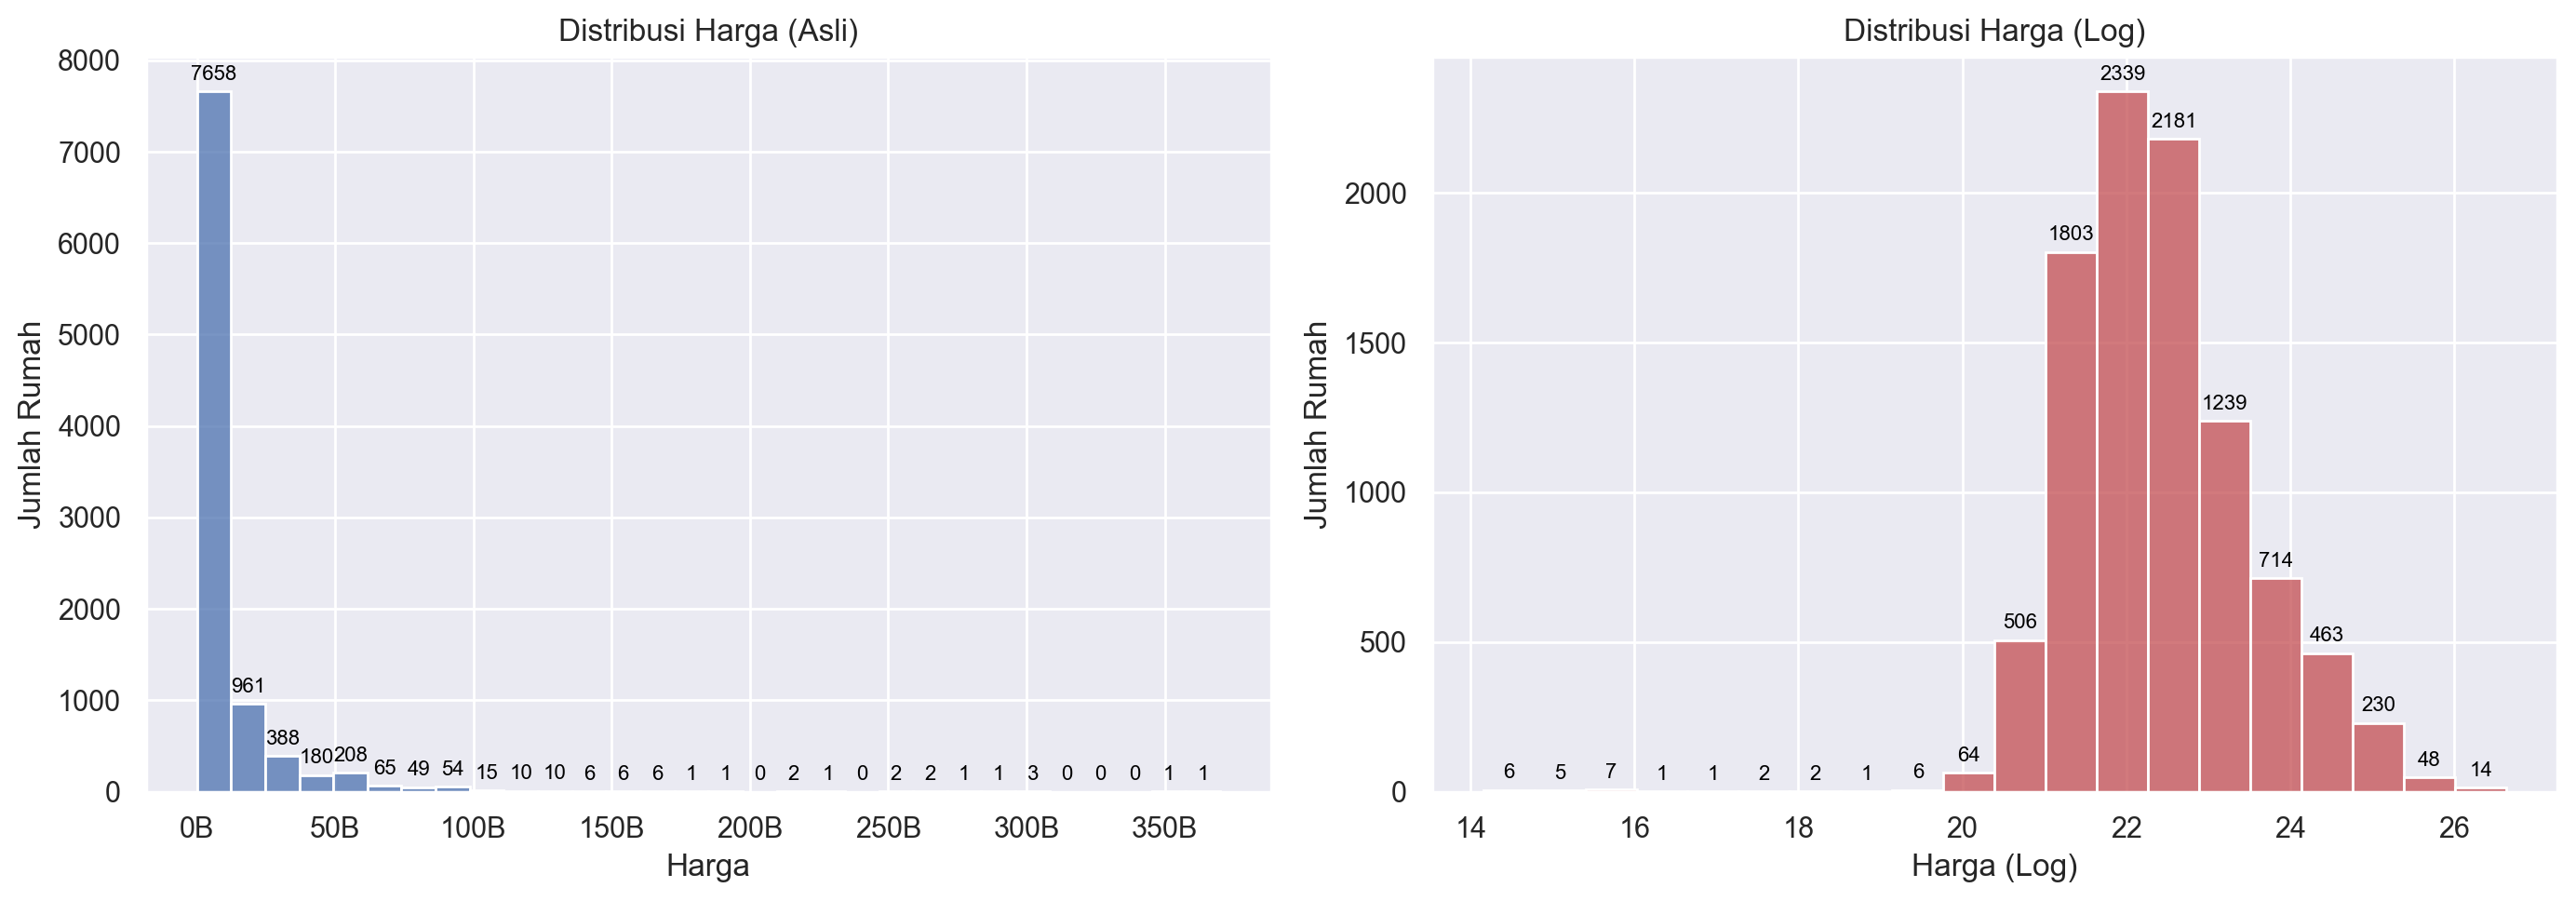

In [342]:
# Membuat figure dengan 1 baris 2 kolom dengan lebar 12 dan tinggi 5
fig , axes = plt.subplots(1,2,figsize=(14,5),dpi=200)

# Membuat axes pertama untuk menampilkan distribusi dengan nilai asli
sns.histplot(df['price_idr'],bins=30,color='b',ax=axes[0])
axes[0].bar_label(axes[0].containers[0],fontsize=8,color='black',padding=3)
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e9:.0f}B'))
axes[0].set_title('Distribusi Harga (Asli)')
axes[0].set_xlabel('Harga')
axes[0].set_ylabel('Jumlah Rumah')

# Membuat axes kedua untuk menampilkan distribusi dengan nilai log
sns.histplot(np.log1p(df['price_idr']),bins=20,color='r',ax=axes[1])
axes[1].bar_label(axes[1].containers[0],fontsize=8,color='black',padding=3)
axes[1].set_title('Distribusi Harga (Log)')
axes[1].set_xlabel('Harga (Log)')
axes[1].set_ylabel('Jumlah Rumah')

# Memberi jarak terhadap axes
fig.tight_layout()
plt.show()

### Mencari outliers menggunakan IQR (interquartile range) karena data harga asli right-skew atau tidak terdistribusi dengan normal untuk keperluan EDA

In [343]:
Q1 = df['price_idr'].quantile(0.25)
Q3 = df['price_idr'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price_idr'] < lower) | (df['price_idr'] > upper)]
outliers_high = df[df['price_idr'] > upper]
outliers_low = df[df['price_idr'] < lower]
print(f'Batas Bawah: {lower}')
print(f'Batas Atas: {upper}')
print(f'Jumlah Total Outlier: {len(outliers)}')
print(f'Jumlah Outlier Di Bawah Batas Bawah: {len(outliers_low)}') 
print(f'Jumlah Outlier Di Atas Batas Atas: {len(outliers_high)}') 

Batas Bawah: -8487500000.0
Batas Atas: 20932500000.0
Jumlah Total Outlier: 1179
Jumlah Outlier Di Bawah Batas Bawah: 0
Jumlah Outlier Di Atas Batas Atas: 1179


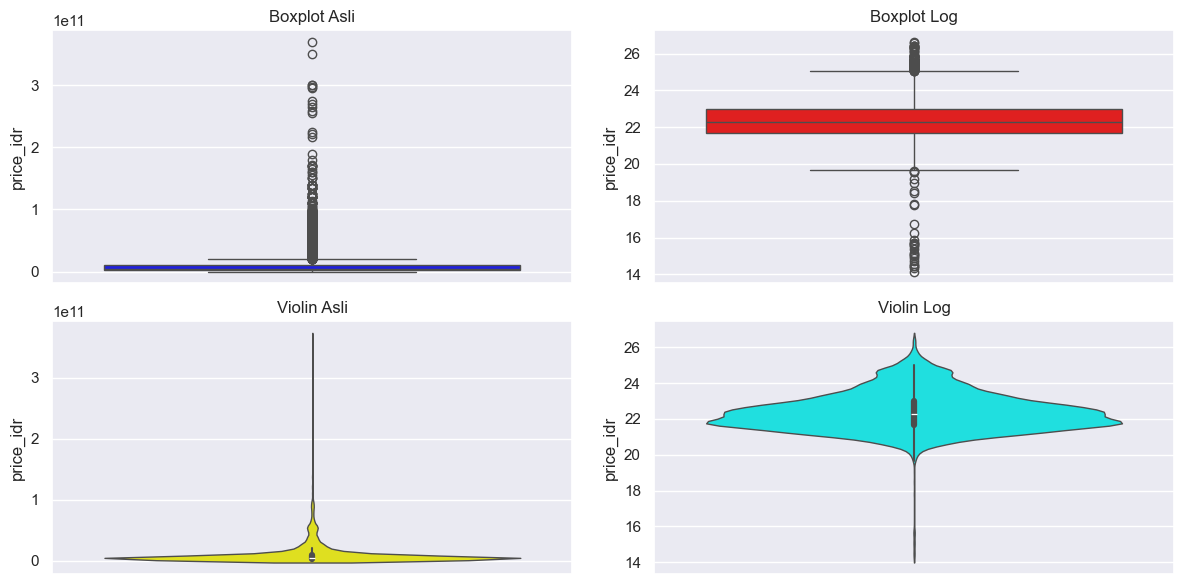

In [344]:

fig , ax = plt.subplots(2,2,figsize=(12,6))

sns.boxplot(y=df['price_idr'],ax=ax[0,0],color='blue')
ax[0,0].set_title('Boxplot Asli')

sns.boxplot(y=np.log1p(df['price_idr']),ax=ax[0,1],color='red')
ax[0,1].set_title('Boxplot Log')

sns.violinplot(y=df['price_idr'],ax=ax[1,0],bw_adjust=1, cut=1, linewidth=1,color='yellow')
ax[1,0].set_title('Violin Asli')

sns.violinplot(y=np.log1p(df['price_idr']),ax=ax[1,1],cut=1, linewidth=1,color='cyan')
ax[1,1].set_title('Violin Log')

plt.tight_layout()
plt.show()

## Insight Visualisasi Boxplot & Violin:
### Nilai Asli : Menunjukan kepadatan harga di antara 0-50M
### Nilai Log : Menunjukan sebaran harga terdistribusi dengan normal dan tidak menumpuk

## Mencari informasi data yang outliers

In [345]:
outliers.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2
count,1.179000e+03,1179.000000,1179.0000,1179.000000,1179.000000,1179.000000
mean,4.962943e+10,6.051739,5.1162,3.590331,897.063613,804.072095
std,3.719431e+10,7.066855,4.8143,4.081630,1040.171803,660.623814
min,2.100000e+10,1.000000,1.0000,0.000000,30.000000,50.000000
25%,2.700000e+10,4.000000,4.0000,2.000000,540.000000,500.000000
50%,3.900000e+10,5.000000,5.0000,3.000000,719.000000,650.000000
75%,5.600000e+10,6.000000,6.0000,4.000000,983.000000,1000.000000
max,3.700000e+11,117.000000,117.0000,77.000000,21754.000000,12200.000000


In [346]:
na = df[(df['price_idr'] > 100_000_000_000) & ((df['land_size_m2'] < 100) | (df['building_size_m2'] < 100))]
na

,title,price_idr,city,district,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,scraped_at
3921,Rumah City Resort Dijual Murah dan Cepat,2.950000e+11,Jakarta Barat,Cengkareng,3.0,2.0,1.0,90.0,180.0,2026-04-23T16:47:57.676269+00:00
8139,Rumah Modern Kualitas Mewah di Cempaka Putih P...,1.020000e+11,Jakarta Pusat,Cempaka Putih,2.0,2.0,1.0,30.0,58.0,2026-04-23T22:19:26.868123+00:00


In [347]:
df = df.drop(index=na.index)

In [348]:
df.info()

<class 'pandas.DataFrame'>
Index: 9630 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             9630 non-null   str    
 1   price_idr         9630 non-null   float64
 2   city              9630 non-null   str    
 3   district          9630 non-null   str    
 4   bedrooms          9630 non-null   float64
 5   bathrooms         9630 non-null   float64
 6   garage            9630 non-null   float64
 7   land_size_m2      9630 non-null   float64
 8   building_size_m2  9630 non-null   float64
 9   scraped_at        9630 non-null   str    
dtypes: float64(6), str(4)
memory usage: 827.6 KB


In [349]:
df.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2
count,9.630000e+03,9630.000000,9630.000000,9630.000000,9630.000000,9630.000000
mean,1.080474e+10,4.459398,3.663136,1.776324,291.813915,325.993458
std,1.964421e+10,3.926572,3.242496,2.016502,460.474206,346.612246
min,1.400000e+06,1.000000,1.000000,0.000000,30.000000,30.000000
25%,2.535000e+09,3.000000,2.000000,1.000000,105.000000,145.000000
50%,4.750000e+09,4.000000,3.000000,1.000000,178.000000,230.000000
75%,9.900000e+09,5.000000,4.000000,2.000000,330.000000,400.000000
max,3.700000e+11,117.000000,117.000000,77.000000,21754.000000,12200.000000


In [350]:
df['title'] = df['title'].str.lower()
df['cluster'] = df['title'].str.contains('cluster', na=False).astype(int)
df['pool'] = df['title'].str.contains(r'kolam renang|pool', na=False).astype(int)
df['mrt'] = df['title'].str.contains(r'mrt', na=False).astype(int)
df['tol'] = df['title'].str.contains(r'tol', na=False).astype(int)
df['furnished'] = df['title'].str.contains(r'furnished', na=False).astype(int)
df['mall'] = df['title'].str.contains(r'mall', na=False).astype(int)
df['kos'] = df['title'].str.contains(r'kos|kost|kostan|kosan', na=False).astype(int)
df['rumah_sakit'] = (df['title'].str.contains(r'rumah sakit', na=False) &~ df['title'].str.contains(r'dekat|near|sekitar|selangkah', na=False)).astype(int)

In [351]:
df[(df['kos'] == 1) | (df['rumah_sakit'] == 1)]

,title,price_idr,city,district,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,scraped_at,cluster,pool,mrt,tol,furnished,mall,kos,rumah_sakit
91,"rumah tinggal dan ada kamar kos di ciomas, keb...",9.800000e+09,Jakarta Selatan,Kebayoran Baru,15.0,4.0,2.0,200.0,200.0,2026-04-23T11:36:02.181644+00:00,0,0,0,0,0,0,1,0
126,dijual rumah beserta rumah kos dijati padang j...,6.500000e+09,Jakarta Selatan,Jati Padang,14.0,13.0,6.0,600.0,250.0,2026-04-23T11:38:43.826644+00:00,0,0,0,0,0,0,1,0
153,dijual rumah kost di kemang,6.500000e+09,Jakarta Selatan,Kemang,17.0,12.0,8.0,378.0,250.0,2026-04-23T11:40:39.258995+00:00,0,0,0,0,0,0,1,0
208,rumah kost dijual jl madrasah dekat akses mrt ...,8.000000e+09,Jakarta Selatan,Cilandak,15.0,15.0,1.0,344.0,580.0,2026-04-23T11:44:50.784138+00:00,0,0,1,0,0,0,1,0
232,"rumah kost tebet 10 kamar tidur, fully renovat...",3.900000e+09,Jakarta Selatan,Tebet,9.0,5.0,1.0,126.0,250.0,2026-04-23T11:46:36.631292+00:00,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9968,dijual rumah dan kosan hadap timur di menteng,5.500000e+10,Jakarta Pusat,Menteng,18.0,2.0,8.0,732.0,1200.0,2026-04-24T00:56:48.585434+00:00,0,0,0,0,0,0,1,0
9970,dijual rumah semi kosan luas dan terawat,5.000000e+10,Jakarta Pusat,Menteng,16.0,2.0,6.0,909.0,648.0,2026-04-24T00:56:59.176513+00:00,0,0,0,0,0,0,1,0
9975,dijual rumah dan kosan exclusive di menteng,1.800000e+10,Jakarta Pusat,Menteng,12.0,12.0,0.0,242.0,300.0,2026-04-24T00:57:21.824767+00:00,0,0,0,0,0,0,1,0
9992,dijual rumah cocok utk buka tempat kost,2.750000e+09,Jakarta Pusat,Karang Anyar,5.0,2.0,0.0,189.0,189.0,2026-04-24T00:58:52.840882+00:00,0,0,0,0,0,0,1,0


In [352]:
df = df[(df['rumah_sakit'] == 0) & (df['kos'] == 0)]
df = df.drop(columns=['rumah_sakit','kos'])
df.info()

<class 'pandas.DataFrame'>
Index: 9319 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             9319 non-null   str    
 1   price_idr         9319 non-null   float64
 2   city              9319 non-null   str    
 3   district          9319 non-null   str    
 4   bedrooms          9319 non-null   float64
 5   bathrooms         9319 non-null   float64
 6   garage            9319 non-null   float64
 7   land_size_m2      9319 non-null   float64
 8   building_size_m2  9319 non-null   float64
 9   scraped_at        9319 non-null   str    
 10  cluster           9319 non-null   int64  
 11  pool              9319 non-null   int64  
 12  mrt               9319 non-null   int64  
 13  tol               9319 non-null   int64  
 14  furnished         9319 non-null   int64  
 15  mall              9319 non-null   int64  
dtypes: float64(6), int64(6), str(4)
memory usage: 1.2 MB


## Melihat Korelasi antar kolom
### Deskripsi:
### 0,00 – 0,25: Korelasi sangat lemah
### 0,25 – 0,50: Korelasi cukup/sedang
### 0,50 – 0,75: Korelasi kuat
### 0,75 – 0,99: Korelasi sangat kuat
### 1,00: Korelasi sempurna
### Note : Korelasi hanya menilai hubungungan antar 2 kolom bukan seluruh kolom, jadi jika korelasi lemah bukan berarti fitur tidak berguna

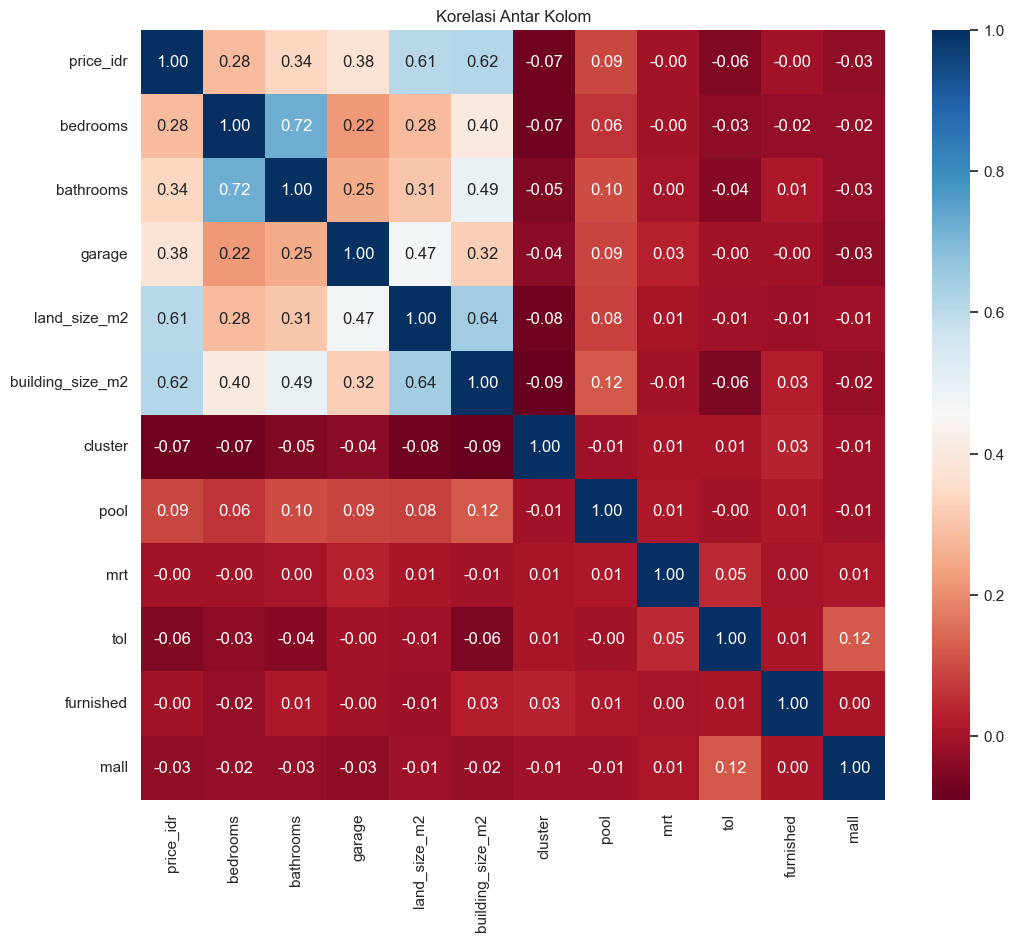

In [353]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='RdBu', fmt='.2f')
plt.title('Korelasi Antar Kolom')
plt.show()

In [354]:
df.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,cluster,pool,mrt,tol,furnished,mall
count,9.319000e+03,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000
mean,1.088353e+10,4.158493,3.443181,1.765211,292.095182,323.583968,0.068248,0.018779,0.009014,0.031978,0.043138,0.020067
std,1.988044e+10,2.021905,1.680017,1.969566,464.113388,340.808169,0.252184,0.135750,0.094517,0.175950,0.203178,0.140235
min,1.400000e+06,1.000000,1.000000,0.000000,30.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.500000e+09,3.000000,2.000000,1.000000,105.000000,144.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.700000e+09,4.000000,3.000000,1.000000,176.000000,228.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.900000e+09,5.000000,4.000000,2.000000,330.000000,400.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3.700000e+11,80.000000,48.000000,77.000000,21754.000000,12200.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Melihat distribusi atau sebaran kolom lain menggunakan histoplot

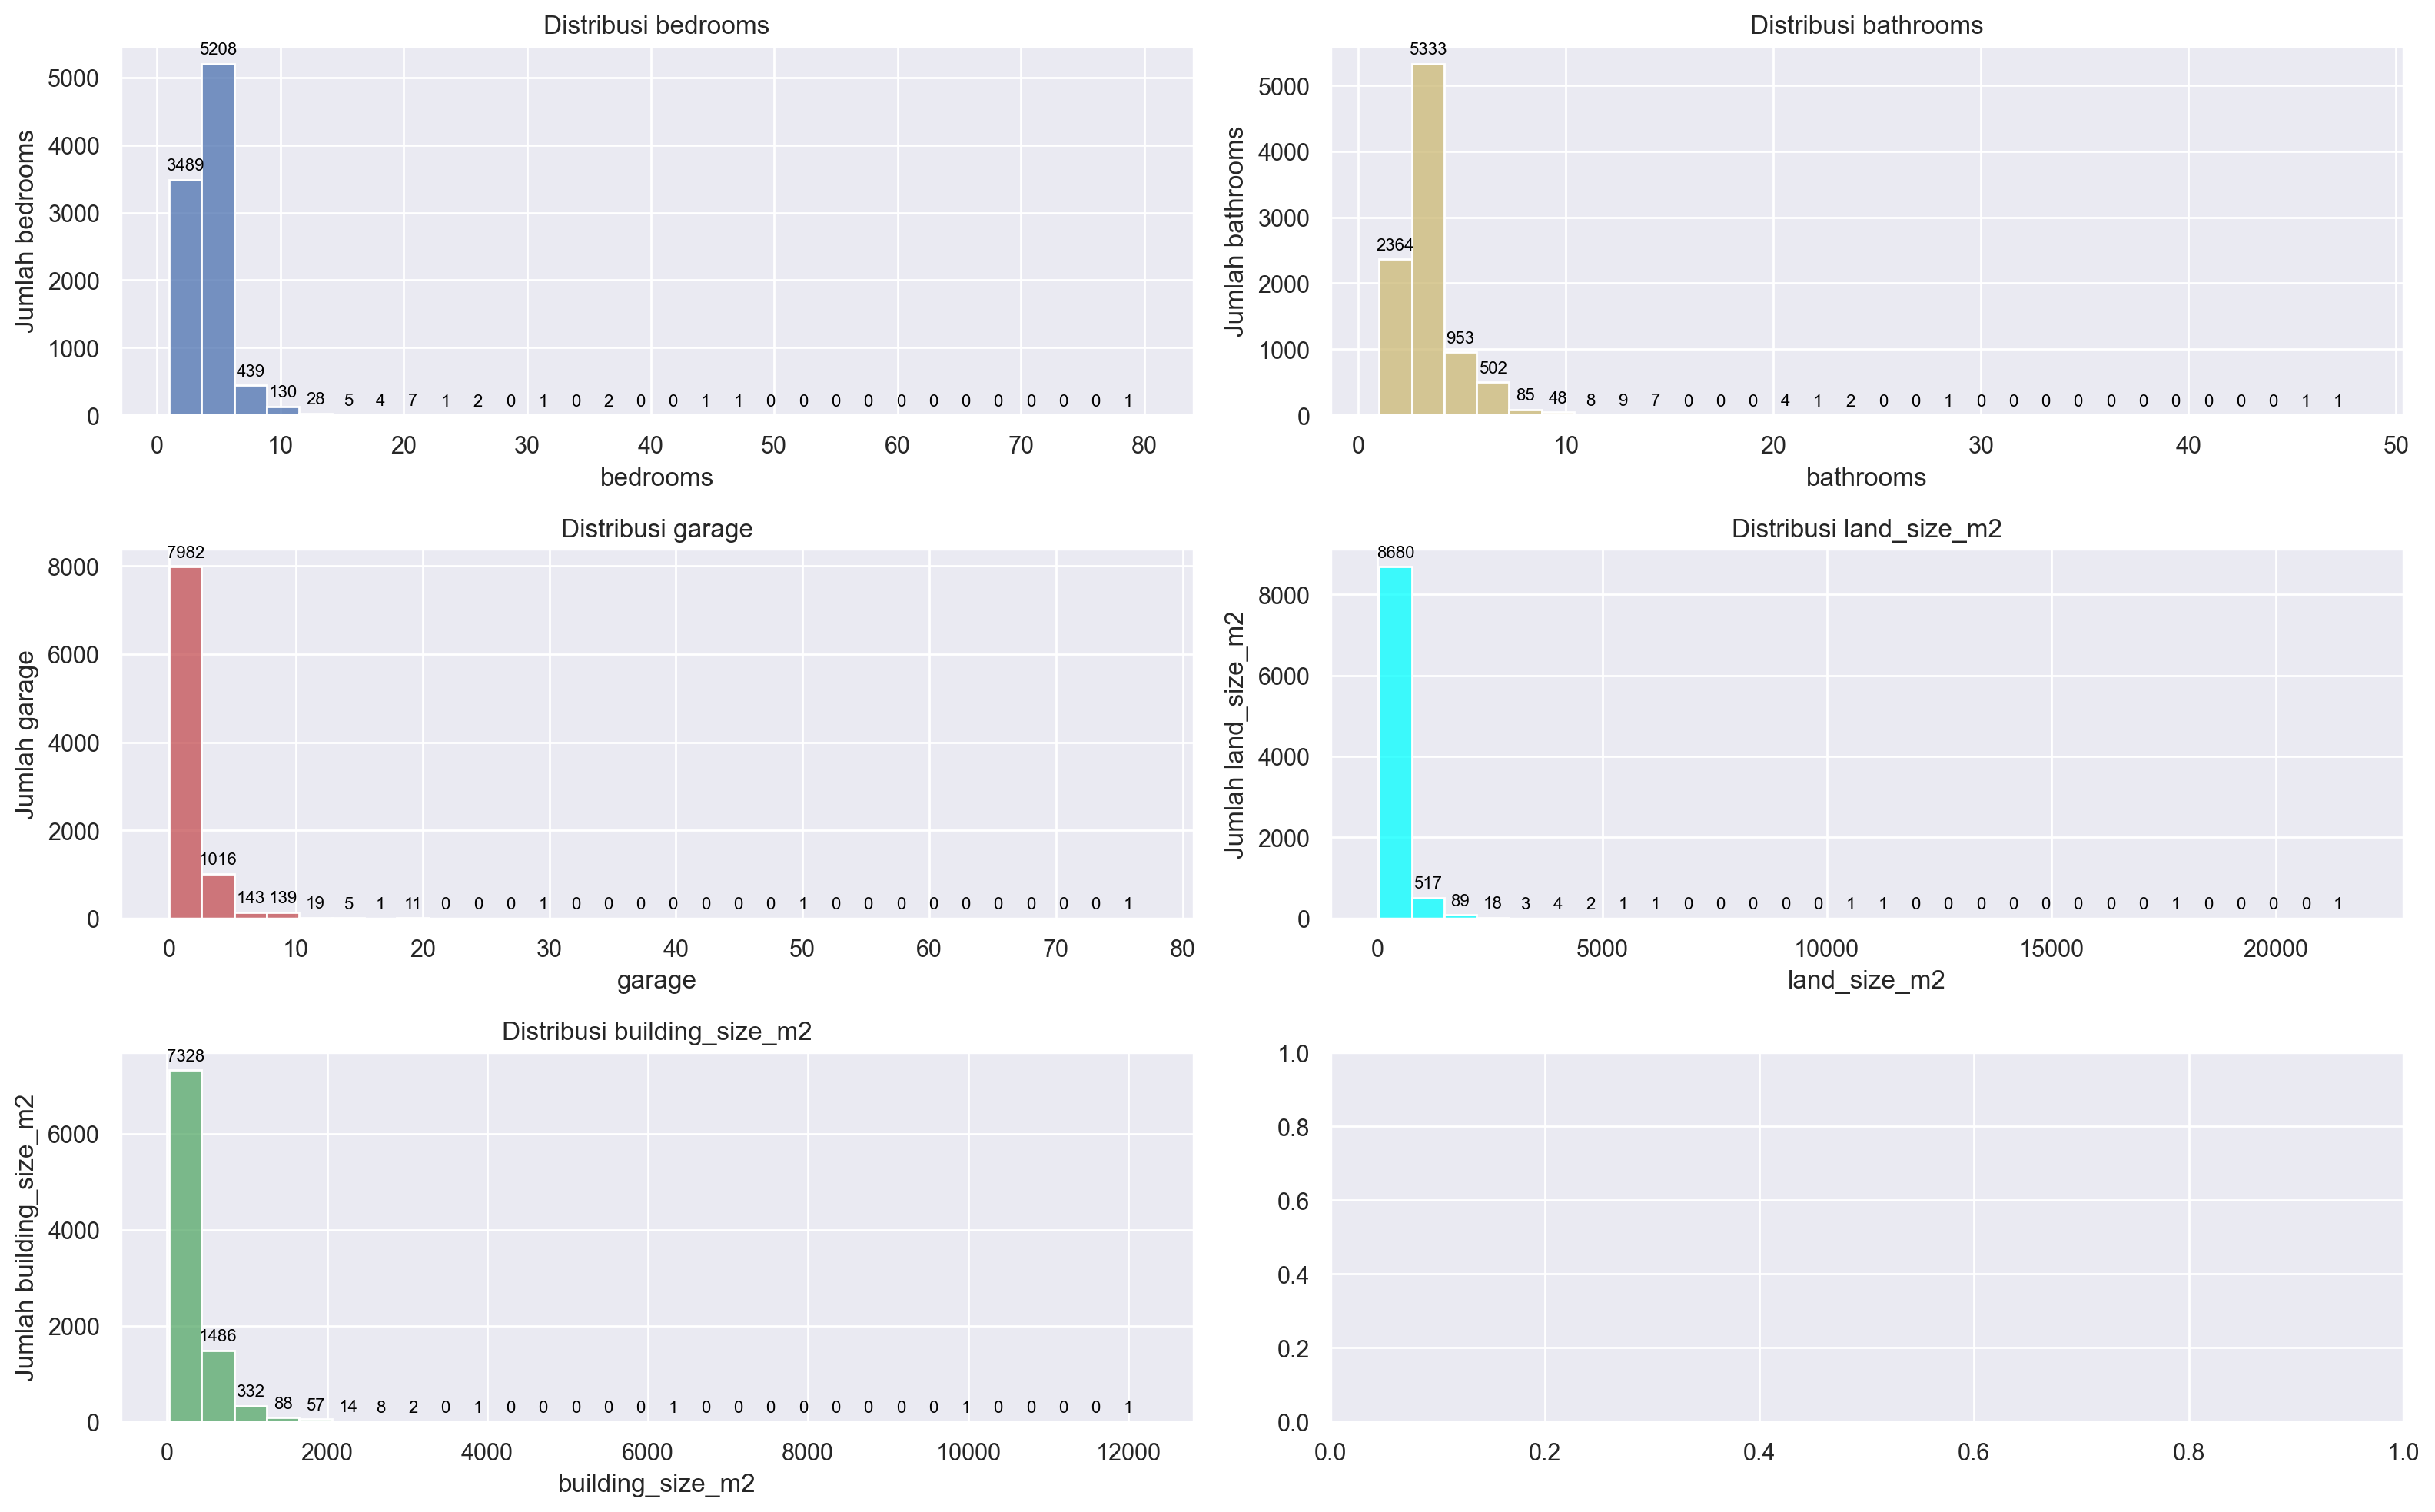

In [355]:
fig , axes = plt.subplots(3,2,figsize=(16,10),dpi=200)
axes = axes.flatten()

columns = ['bedrooms','bathrooms','garage','land_size_m2','building_size_m2']
collor = ['b','y','r','cyan','g']
col = zip(columns,collor)
n = 0

for k,v in col:
    sns.histplot(df[k],bins=30,color=v,ax=axes[n])
    axes[n].bar_label(axes[n].containers[0],fontsize=8,color='black',padding=3)
    axes[n].set_ylabel(f'Jumlah {k}')
    axes[n].set_title(f'Distribusi {k}')
    n = n+1

fig.tight_layout()
plt.show()


In [356]:
df[df['garage'] > 10][['bedrooms', 'bathrooms', 'garage', 'land_size_m2', 'price_idr']]

,bedrooms,bathrooms,garage,land_size_m2,price_idr
23,6.0,4.0,20.0,2360.0,4.800000e+10
46,16.0,20.0,15.0,1493.0,2.600000e+10
187,6.0,3.0,15.0,1493.0,2.590000e+10
272,16.0,9.0,15.0,1493.0,2.600000e+10
283,4.0,2.0,15.0,610.0,6.500000e+10
402,7.0,7.0,11.0,1986.0,3.000000e+10
404,7.0,7.0,11.0,1800.0,5.500000e+10
481,1.0,1.0,20.0,5555.0,5.500000e+10
485,6.0,6.0,12.0,1925.0,4.200000e+10
539,5.0,3.0,12.0,10350.0,5.500000e+10


## Memfilter atau memberi batas dan juga transformisasi pada kolom yang dibutuhkan untuk membuat distribusi menjadi normal

In [357]:
df['bedrooms']  = df['bedrooms'].clip(upper=20)
df['bathrooms'] = df['bathrooms'].clip(upper=20)
df['garage']    = df['garage'].clip(upper=20)

df['land_size_log']     = np.log1p(df['land_size_m2'])
df['building_size_log'] = np.log1p(df['building_size_m2'])

## Disribusi atau sebaran setiap kolom setelah melakukan normalisasi dengan cara clip dan log


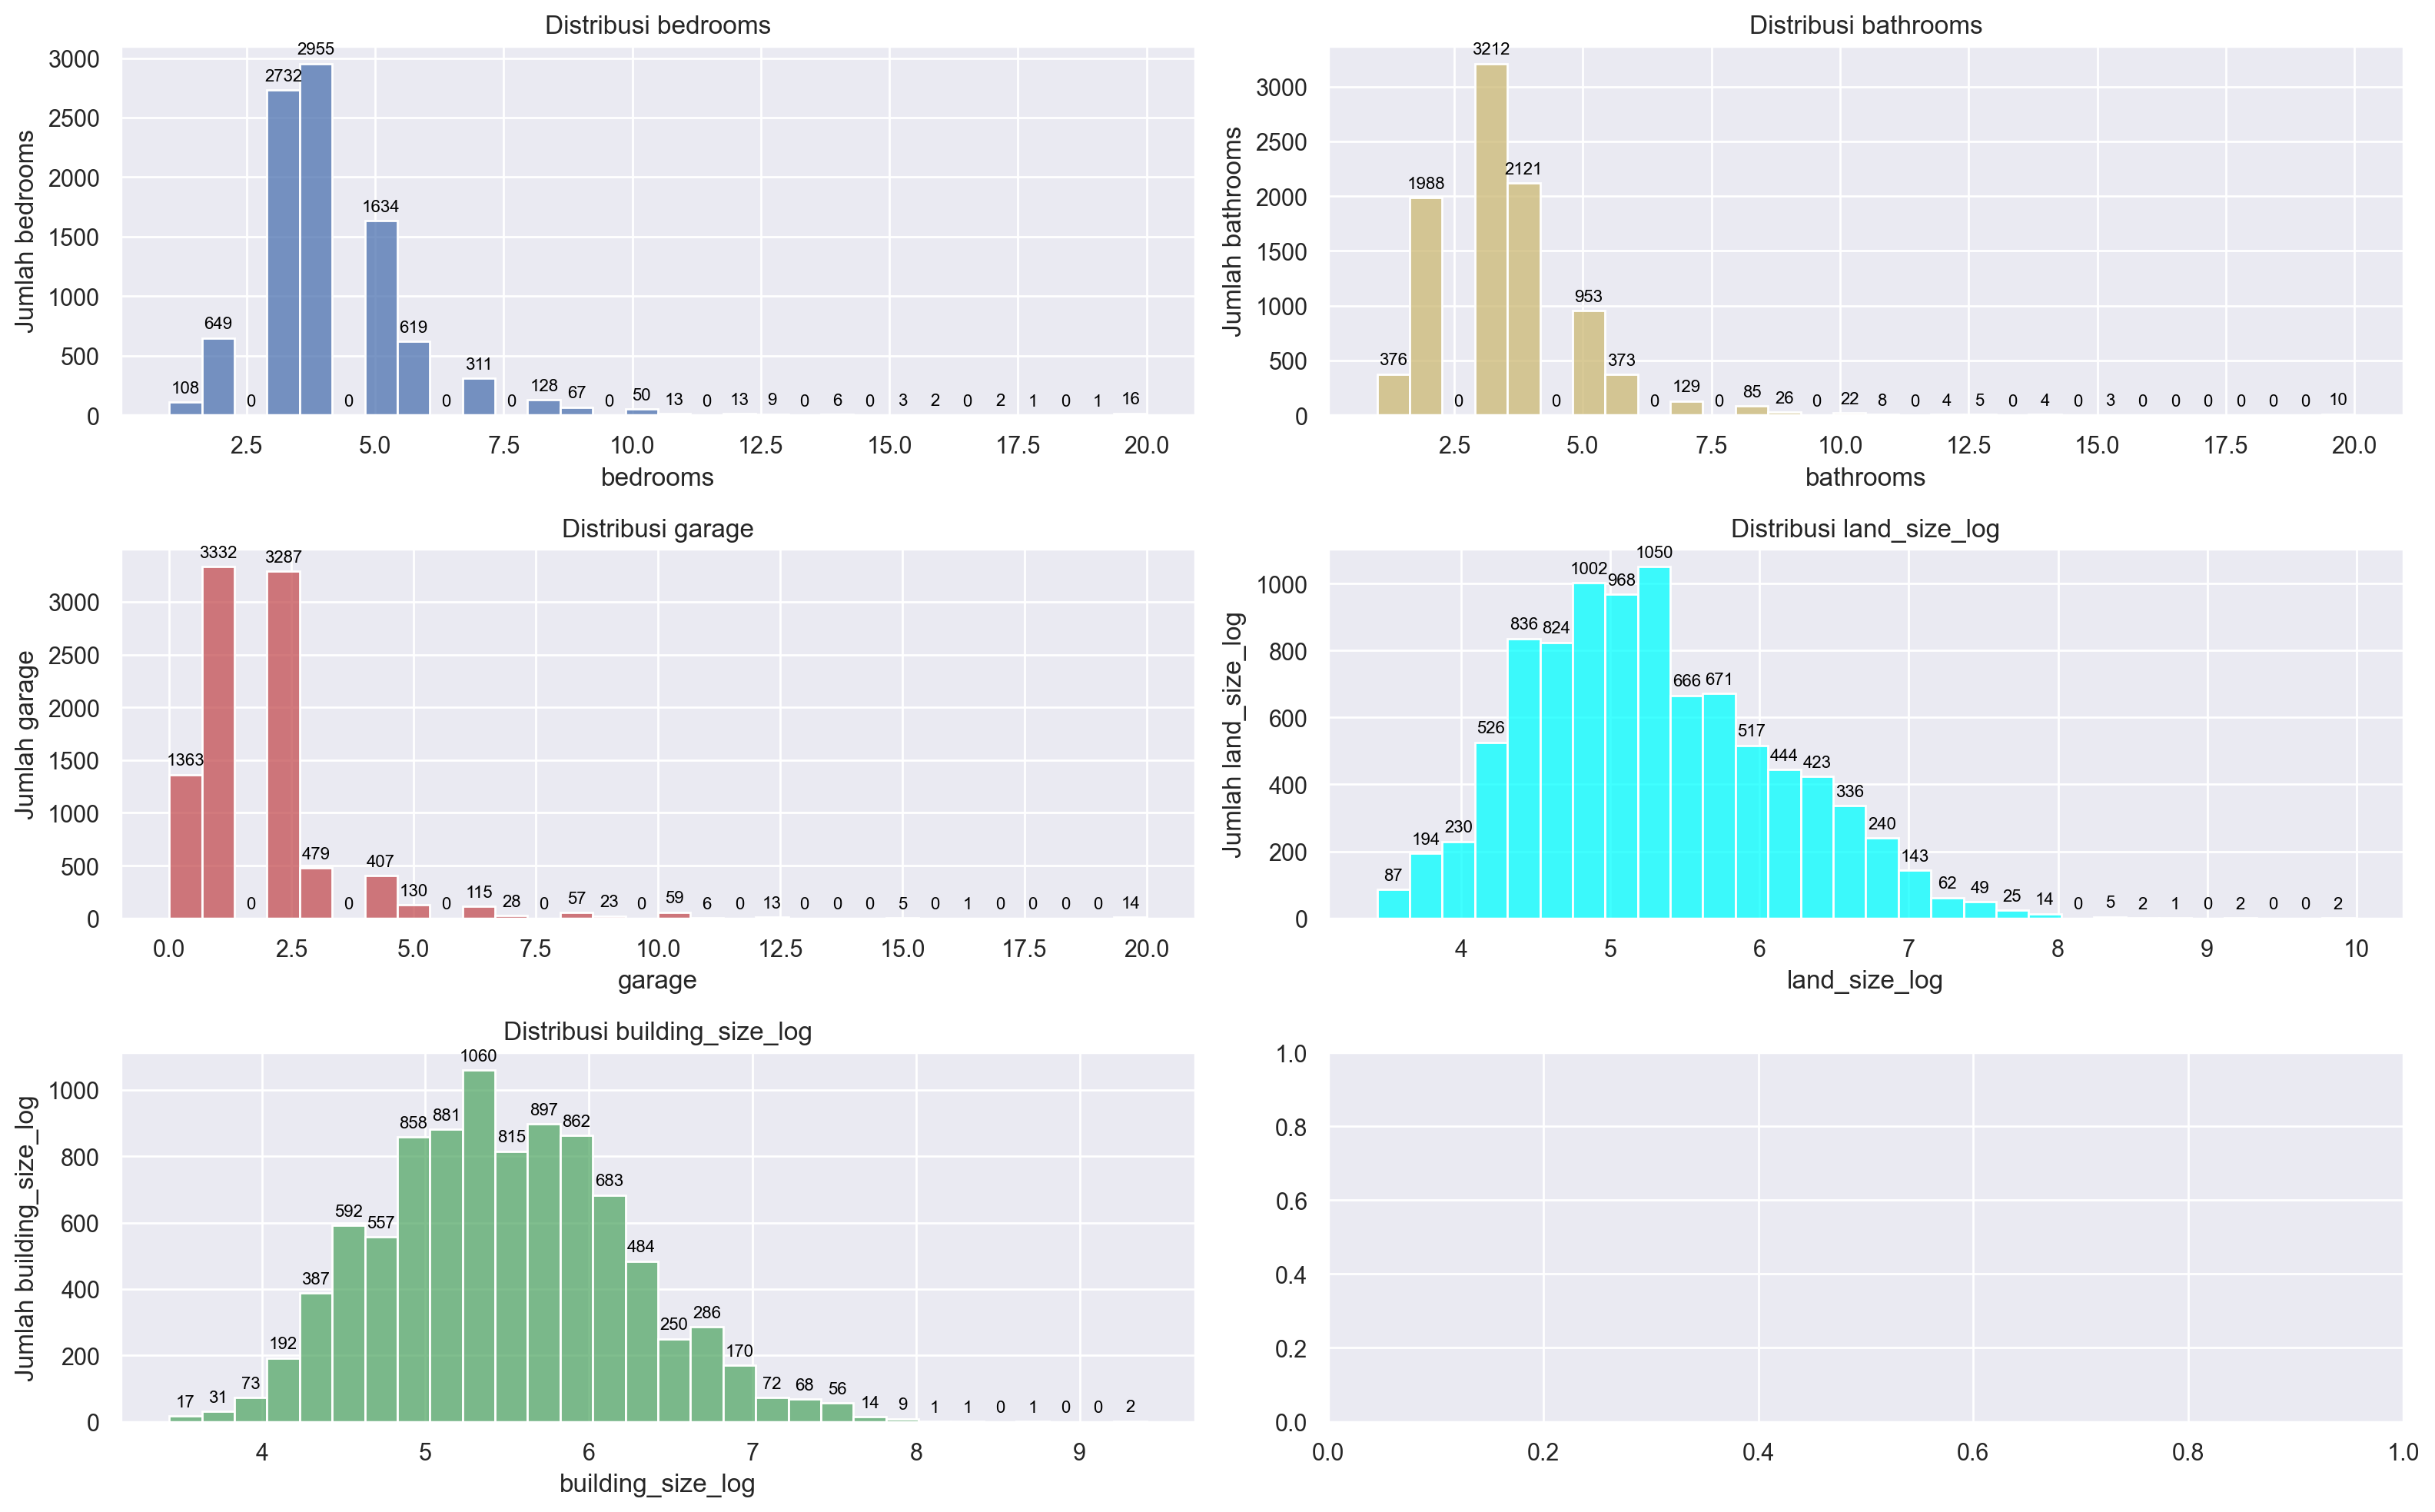

In [358]:
fig , axes = plt.subplots(3,2,figsize=(16,10),dpi=200)
axes = axes.flatten()

columns = ['bedrooms','bathrooms','garage','land_size_log','building_size_log']
collor = ['b','y','r','cyan','g']
col = zip(columns,collor)
n = 0

for k,v in col:
    sns.histplot(df[k],bins=30,color=v,ax=axes[n])
    axes[n].bar_label(axes[n].containers[0],fontsize=8,color='black',padding=3)
    axes[n].set_ylabel(f'Jumlah {k}')
    axes[n].set_title(f'Distribusi {k}')
    n = n+1

fig.tight_layout()
plt.show()

In [359]:
df.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,cluster,pool,mrt,tol,furnished,mall,land_size_log,building_size_log
count,9.319000e+03,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000
mean,1.088353e+10,4.139715,3.435347,1.754802,292.095182,323.583968,0.068248,0.018779,0.009014,0.031978,0.043138,0.020067,5.269419,5.484015
std,1.988044e+10,1.697633,1.549110,1.744544,464.113388,340.808169,0.252184,0.135750,0.094517,0.175950,0.203178,0.140235,0.844933,0.744414
min,1.400000e+06,1.000000,1.000000,0.000000,30.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.433987,3.433987
25%,2.500000e+09,3.000000,2.000000,1.000000,105.000000,144.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.663439,4.976734
50%,4.700000e+09,4.000000,3.000000,1.000000,176.000000,228.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.176150,5.433722
75%,9.900000e+09,5.000000,4.000000,2.000000,330.000000,400.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.802118,5.993961
max,3.700000e+11,20.000000,20.000000,20.000000,21754.000000,12200.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9.987599,9.409273


In [ ]:
low, high = df['price_idr'].quantile([0.01, 0.99])
print(low, high)

df['price_idr'] = df['price_idr'].clip(low, high)

900000000.0 68000000000.0


In [361]:
df = pd.get_dummies(df, columns=['city'], dtype=int)

## Menghapus kolom yang tidak butuhkan untuk tahap training model


In [ ]:
df = df.drop(columns=['scraped_at','title'])

# Save data yang bersih ke CSV

In [ ]:
df.to_csv('../dataset/jakarta_properties_clear.csv',index=False)